In [104]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

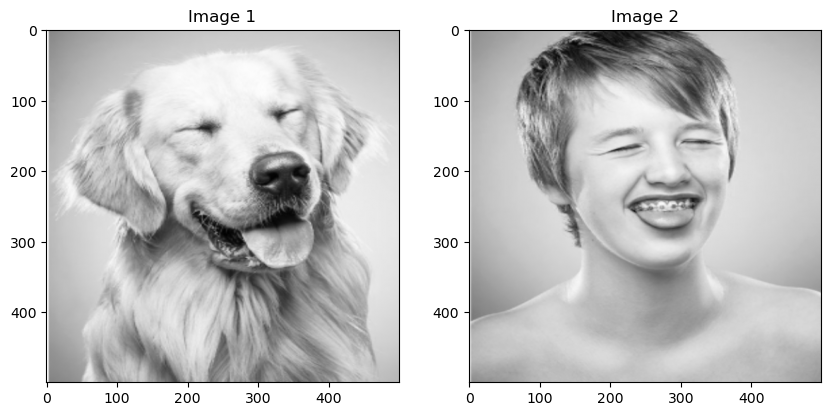

In [105]:
img1=cv2.imread(r"C:\Users\KRISHNA AGARWAL\OneDrive\Pictures\Screenshots\Dog.png")
img2=cv2.imread(r"C:\Users\KRISHNA AGARWAL\OneDrive\Pictures\Screenshots\human.png")

#resize to make both of same size
img1=cv2.resize(img1,(500,500))
img2=cv2.resize(img2,(500,500))

#convert to grayscalr for  simplicity of pixels 

gray1 = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Image 1")
plt.imshow(gray1,cmap='gray')

plt.subplot(1,2,2)
plt.title("Image 2")
plt.imshow(gray2,cmap='gray')

plt.show()



In [106]:
import importlib
import hybrid

importlib.reload(hybrid)
from hybrid import create_hybrid

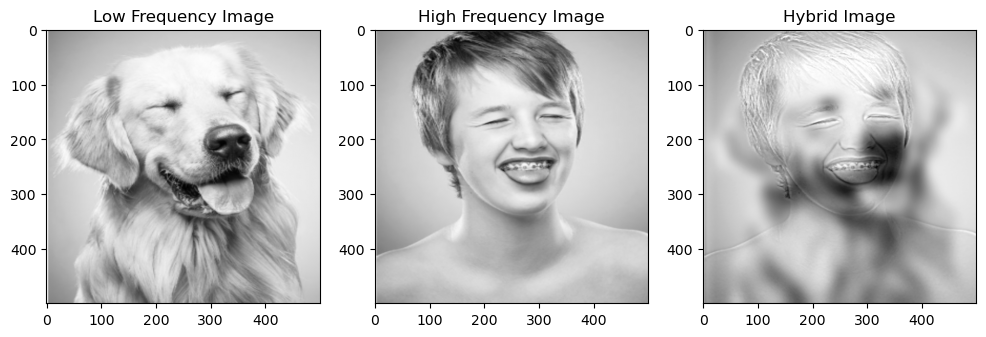

In [107]:
# Create hybrid image
hybrid = create_hybrid(gray1, gray2)

# Display
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Low Frequency Image")
plt.imshow(gray1, cmap='gray')

plt.subplot(1,3,2)
plt.title("High Frequency Image")
plt.imshow(gray2, cmap='gray')

plt.subplot(1,3,3)
plt.title("Hybrid Image")
plt.imshow(hybrid, cmap='gray')

plt.show()

In [116]:
import importlib
import utils

importlib.reload(utils)
from utils import compute_fft
from utils import frequency_filter

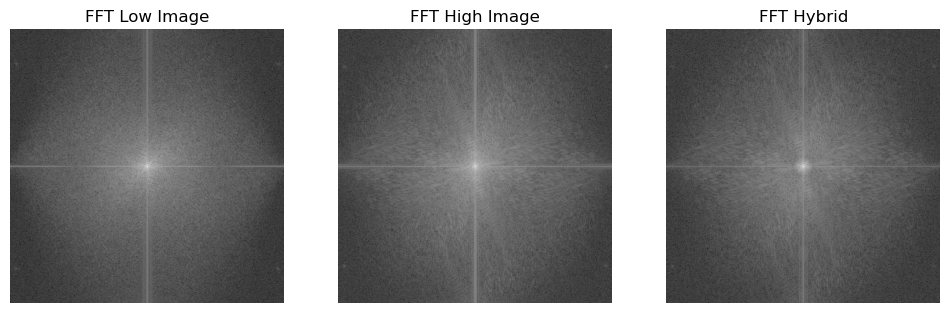

In [117]:
fft1 = compute_fft(gray1)
fft2 = compute_fft(gray2)
fft_hybrid = compute_fft(hybrid)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("FFT Low Image")
plt.imshow(fft1, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("FFT High Image")
plt.imshow(fft2, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("FFT Hybrid")
plt.imshow(fft_hybrid, cmap='gray')
plt.axis('off')

plt.show()

In [124]:
low_freq = frequency_filter(gray1, radius=50, high_pass=False)
high_freq = frequency_filter(gray2, radius=10, high_pass=True)

hybrid_fft = low_freq +1.5* high_freq
hybrid_fft = cv2.normalize(hybrid_fft, None, 0, 255, cv2.NORM_MINMAX)
hybrid_fft = hybrid_fft.astype(np.uint8)

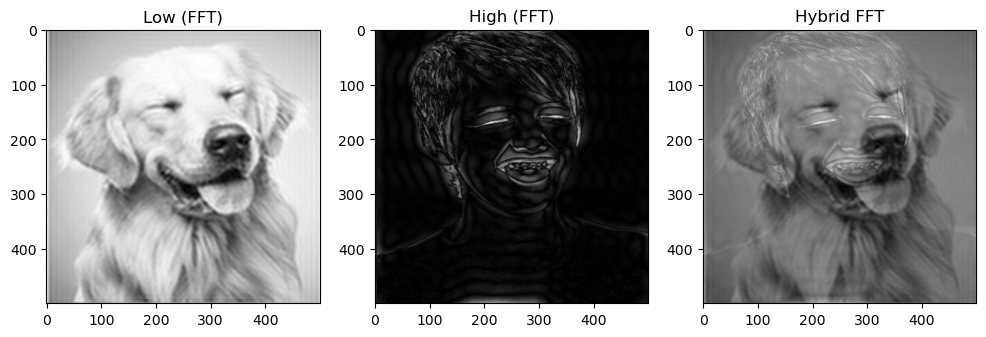

In [125]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Low (FFT)")
plt.imshow(low_freq, cmap='gray')

plt.subplot(1,3,2)
plt.title("High (FFT)")
plt.imshow(high_freq, cmap='gray')

plt.subplot(1,3,3)
plt.title("Hybrid FFT")
plt.imshow(hybrid_fft, cmap='gray')

plt.show()